In [2]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

### imorting dataset

In [3]:
BEED_df=pd.read_csv('BEED_Data.csv')

In [4]:
BEED_df.head(10)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0
5,-47,-52,-45,-41,-29,-24,-21,-19,-13,-3,-2,4,11,14,11,14,0
6,-67,-30,7,33,51,79,105,122,132,115,83,42,10,-22,-47,-57,0
7,72,60,67,69,55,46,30,23,31,40,51,54,65,69,60,50,0
8,56,14,-12,-38,-73,-115,-137,-130,-78,-18,33,85,132,196,244,258,0
9,-17,-16,-12,13,53,84,77,57,24,-20,-39,-45,-40,-35,-19,-4,0


In [5]:
BEED_df.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'y'],
      dtype='object')

In [6]:
BEED_df.dtypes

X1     int64
X2     int64
X3     int64
X4     int64
X5     int64
X6     int64
X7     int64
X8     int64
X9     int64
X10    int64
X11    int64
X12    int64
X13    int64
X14    int64
X15    int64
X16    int64
y      int64
dtype: object

In [8]:
BEED_df['y'].value_counts()

y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64

### selecting feature and target and scaling

In [5]:
X=BEED_df.drop(columns=['y'])
y=BEED_df['y'].astype(np.float32)

In [6]:
scaler=StandardScaler()

In [7]:
X_scaled=scaler.fit_transform(X).astype(np.float32)

In [9]:
type(y)

pandas.core.series.Series

### train test split

In [11]:
X_train,X_test,y_train,y_test=train_test_split(
    X_scaled,y.values,test_size=0.2,random_state=42,stratify=y
)

In [12]:
X_train,X_val,y_train,y_val=train_test_split(
    X_train,y_train,test_size=0.2,random_state=42,stratify=y_train
)

In [13]:
print(f"Training Features (X_train):   {X_train.shape}")
print(f"Validation Features (X_val): {X_val.shape}")
print(f"Test Features (X_test):      {X_test.shape}")
print(f"\nTraining Labels (y_train):     {y_train.shape}")
print(f"Validation Labels (y_val):   {y_val.shape}")
print(f"Test Labels (y_test):        {y_test.shape}")

Training Features (X_train):   (5120, 16)
Validation Features (X_val): (1280, 16)
Test Features (X_test):      (1600, 16)

Training Labels (y_train):     (5120,)
Validation Labels (y_val):   (1280,)
Test Labels (y_test):        (1600,)


### pytorch set

In [28]:

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).long())
val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val).long())
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test).long())



### dataloader

In [29]:
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


### model

In [30]:
input_features = X_train.shape[1] 
num_cls = 4 

model = nn.Sequential(
    nn.Linear(input_features, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, num_cls)
)

### loss function and optimizer

In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### training loop

In [32]:
epochs = 40
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting model training...")

for epoch in range(1, epochs + 1):
    # Training phase
    model.train()
    running_loss, running_corrects = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc.item())

    # Validation phase
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / len(val_loader.dataset)
    val_epoch_acc = val_corrects.double() / len(val_loader.dataset)
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc.item())

    # Print progress
    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | "
              f"Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}")

print("\nTraining finished.")

Starting model training...
Epoch 01/40 | Train Loss: 1.0602 Acc: 0.5273 | Val Loss: 0.8563 Acc: 0.6695
Epoch 02/40 | Train Loss: 0.7369 Acc: 0.7080 | Val Loss: 0.6492 Acc: 0.7328
Epoch 04/40 | Train Loss: 0.4812 Acc: 0.8023 | Val Loss: 0.4638 Acc: 0.8070
Epoch 06/40 | Train Loss: 0.3779 Acc: 0.8492 | Val Loss: 0.3913 Acc: 0.8445
Epoch 08/40 | Train Loss: 0.3322 Acc: 0.8652 | Val Loss: 0.3511 Acc: 0.8625
Epoch 10/40 | Train Loss: 0.3042 Acc: 0.8762 | Val Loss: 0.3255 Acc: 0.8750
Epoch 12/40 | Train Loss: 0.2822 Acc: 0.8873 | Val Loss: 0.3016 Acc: 0.8852
Epoch 14/40 | Train Loss: 0.2601 Acc: 0.9010 | Val Loss: 0.2824 Acc: 0.8969
Epoch 16/40 | Train Loss: 0.2436 Acc: 0.9074 | Val Loss: 0.2754 Acc: 0.8883
Epoch 18/40 | Train Loss: 0.2312 Acc: 0.9096 | Val Loss: 0.2594 Acc: 0.9031
Epoch 20/40 | Train Loss: 0.2181 Acc: 0.9166 | Val Loss: 0.2437 Acc: 0.9094
Epoch 22/40 | Train Loss: 0.2062 Acc: 0.9230 | Val Loss: 0.2312 Acc: 0.9156
Epoch 24/40 | Train Loss: 0.1979 Acc: 0.9250 | Val Loss: 0.22

### test set eval

In [33]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- 2. Print Classification Report ---
print("--- Classification Report on Test Set ---")

class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3']
print(classification_report(all_labels, all_preds, target_names=class_names))

--- Classification Report on Test Set ---
              precision    recall  f1-score   support

     Class 0       1.00      0.99      1.00       400
     Class 1       0.96      0.96      0.96       400
     Class 2       0.90      0.90      0.90       400
     Class 3       0.87      0.87      0.87       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



### confusion matrix

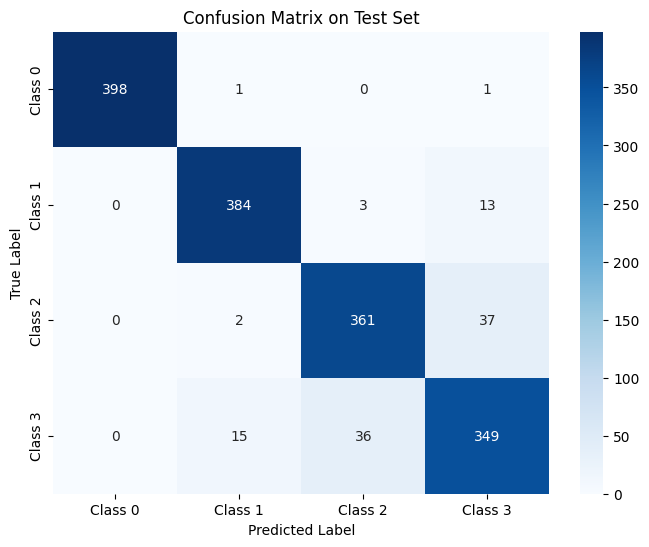

In [34]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

### plotiing learning curves

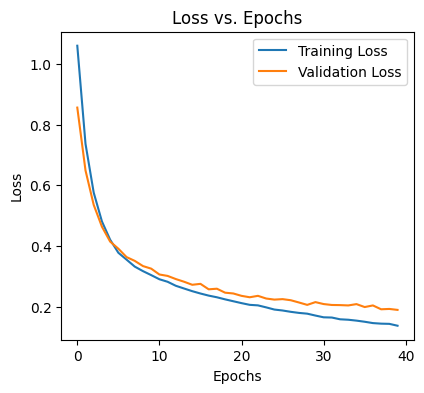

In [35]:
# Plot Loss
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

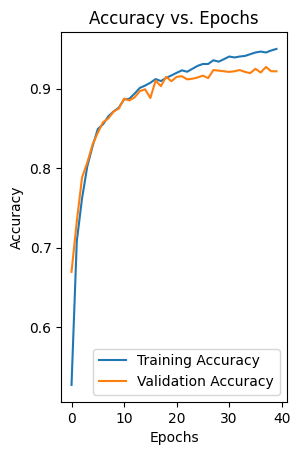

In [36]:
# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()